## Baseline Model

In [ ]:
import warnings

from lightgbm import LGBMClassifier
import pandas as pd
import numpy as np

warnings.filterwarnings("ignore")

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix
from sklearn.ensemble import HistGradientBoostingClassifier, RandomForestClassifier

def eval_classification(y_true, y_pred, name=""):
    acc = accuracy_score(y_true, y_pred)
    f1_macro = f1_score(y_true, y_pred, average="macro")
    f1_weighted = f1_score(y_true, y_pred, average="weighted")
    print(f"{name} Accuracy: {acc:.4f} | F1-macro: {f1_macro:.4f} | F1-weighted: {f1_weighted:.4f}")
    return acc, f1_macro, f1_weighted

def save_preds_csv(X_test, y_true, y_pred, filename):
    out = X_test.copy()
    out["y_true"] = y_true
    out["y_pred"] = y_pred
    out.to_csv(filename, index=False, encoding="utf-8-sig")
    print(f"Saved: {filename}")

def derive_groups_from_train(train_df, k_baseline_dict, min_group_size=2):
    df_temp = train_df.copy()
    df_temp["k_eff_expected"] = df_temp["load"].map(k_baseline_dict)
    if df_temp["k_eff_expected"].isnull().any():
        known_loads = np.array(list(k_baseline_dict.keys()))
        for idx, row in df_temp[df_temp["k_eff_expected"].isnull()].iterrows():
            closest_load = known_loads[np.abs(known_loads - row["load"]).argmin()]
            df_temp.loc[idx, "k_eff_expected"] = k_baseline_dict[closest_load]     
    df_temp["abs_diff"] = (df_temp["efficiency"] - df_temp["k_eff_expected"]).abs()
    type_stats = (
        df_temp.groupby("type")["abs_diff"]
        .agg(n="count", mean="mean")
        .sort_values("mean")
        .reset_index()
    )
    types = type_stats["type"].tolist()
    x = type_stats["mean"].to_numpy()
    n = len(x)
    # Prefix sums for O(1) segment SSE
    S1 = np.concatenate([[0.0], np.cumsum(x)])
    S2 = np.concatenate([[0.0], np.cumsum(x * x)])
    def seg_sse(i, j):
        m = j - i + 1
        sum1 = S1[j + 1] - S1[i]
        sum2 = S2[j + 1] - S2[i]
        mu = sum1 / m
        return sum2 - 2 * mu * sum1 + m * mu * mu

    K = 3
    INF = 1e18
    dp = np.full((K + 1, n + 1), INF)
    cut = np.full((K + 1, n + 1), -1, dtype=int)

    dp[0, 0] = 0.0
    for k in range(1, K + 1):
        for t in range(1, n + 1):
            p_min = (k - 1) * min_group_size
            p_max = t - min_group_size
            if p_max < p_min:
                continue
            best_cost, best_p = INF, -1
            for p in range(p_min, p_max + 1):
                cost = dp[k - 1, p] + seg_sse(p, t - 1)
                if cost < best_cost:
                    best_cost, best_p = cost, p
            dp[k, t] = best_cost
            cut[k, t] = best_p

    if np.isinf(dp[K, n]):
        raise RuntimeError("No valid split found. Try min_group_size=1 or check types count.")
    bounds = []
    t = n
    for k in range(K, 0, -1):
        p = cut[k, t]
        bounds.append((p, t))
        t = p
    bounds.reverse()
    group_names = ["near", "mid", "far"] 
    groups = {}
    for name, (a, b) in zip(group_names, bounds):
        groups[name] = types[a:b]

    type_to_group = {t: g for g, ts in groups.items() for t in ts}
    return type_to_group, groups, type_stats


# ----- Load split files -----
train_random = pd.read_csv('../../../GenerativeModel/WGAN-GPGenData/wpt_train_random_aug_wgangp.csv')
test_random  = pd.read_csv('../../../random-split/wpt_test_random.csv')

# Sanity check expected columns
expected_cols = {"type", "load", "efficiency"}
for name, d in [("train_random", train_random), ("test_random", test_random)]:
    missing = expected_cols - set(d.columns)
    if missing:
        raise ValueError(f"{name} is missing columns: {missing}")

# Make sure numeric columns are numeric
for d in [train_random, test_random]:
    d["load"] = pd.to_numeric(d["load"], errors="coerce")
    d["efficiency"] = pd.to_numeric(d["efficiency"], errors="coerce")
    d["type"] = d["type"].astype(str)
    d.dropna(subset=["type", "load", "efficiency"], inplace=True)

# Features / target
FEATURES = ["load", "efficiency"]
TARGET = "type"

# =========================
def add_advanced_features(df, k_baseline_dict, type_to_group_dict):
    df = df.copy()
    df["k_eff_expected"] = df["load"].map(k_baseline_dict)
    if df["k_eff_expected"].isnull().any():
        known_loads = np.array(list(k_baseline_dict.keys()))
        for idx, row in df[df["k_eff_expected"].isnull()].iterrows():
            closest_load = known_loads[np.abs(known_loads - row["load"]).argmin()]
            df.loc[idx, "k_eff_expected"] = k_baseline_dict[closest_load]  
    # 2. Độ lệch (Difference) và Tỷ lệ (Ratio)
    df["eff_diff"] = df["efficiency"] - df["k_eff_expected"]
    df["eff_ratio"] = df["efficiency"] / df["k_eff_expected"]
    # 3. Ước tính tổn hao công suất (Power Loss Proxy)
    # P_loss = Load * (1 / (Efficiency / 100) - 1)
    df["p_loss"] = df["load"] * (1 / (df["efficiency"] / 100.0) - 1)
    # Tổn hao công suất của Class K
    df["k_p_loss"] = df["load"] * (1 / (df["k_eff_expected"] / 100.0) - 1)
    # Độ lệch suy hao do vật thể lạ gây ra
    df["p_loss_diff"] = df["p_loss"] - df["k_p_loss"]

    df["dist_zone_name"] = df["type"].map(type_to_group_dict).fillna("far")
    # Mã hóa thành số
    zone_mapping = {"near": 1, "mid": 2, "far": 3}
    df["dist_zone"] = df["dist_zone_name"].map(zone_mapping)
    # 4. Phân vùng Dải tải (Load Zone)
    # Giả sử dải tải từ 0.5 đến 3.0, chia làm 3 vùng: Nhẹ (1), Vừa (2), Nặng (3)
    df['load_zone'] = pd.cut(df['load'], bins=3, labels=[1, 2, 3]).astype(float)
    return df

k_baseline_train_r = train_random[train_random["type"] == "K"].groupby("load")["efficiency"].mean().to_dict()
type_to_group, groups_dict, stats = derive_groups_from_train(train_random, k_baseline_train_r)
print("Results of grouping the Types:", groups_dict)

train_random_fe = add_advanced_features(train_random, k_baseline_train_r, type_to_group)
test_random_fe = add_advanced_features(test_random, k_baseline_train_r, type_to_group)

FEATURES_NEW = [
    "load", "efficiency", 
    "eff_diff", "eff_ratio", 
    "p_loss_diff", "load_zone", "dist_zone"
]
# =========================
X_train_r = train_random_fe[FEATURES_NEW]
y_train_r = train_random_fe[TARGET]
X_test_r  = test_random_fe[FEATURES_NEW]
y_test_r  = test_random_fe[TARGET]

Results of grouping the Types: {'near': ['K', 'H', 'J'], 'mid': ['G', 'I', 'F', 'E', 'D', 'B'], 'far': ['C', 'A']}


## Optuna

In [ ]:
import optuna
import lightgbm as lgb
import json
from sklearn.model_selection import StratifiedKFold, cross_val_score

def objective(trial):
    param = {
        'objective': 'multiclass',
        'num_class': 11,
        'metric': 'multi_logloss',
        'verbosity': -1,
        'random_state': 42,
        'class_weight': 'balanced',

        'boosting_type': trial.suggest_categorical('boosting_type', ['gbdt', 'dart']),
        
        'n_estimators': trial.suggest_int('n_estimators', 100, 1500), 
        'learning_rate': trial.suggest_float('learning_rate', 0.001, 0.2, log=True),
        'max_depth': trial.suggest_int('max_depth', 2, 12), 
        'num_leaves': trial.suggest_int('num_leaves', 4, 256),
        
        'lambda_l1': trial.suggest_float('lambda_l1', 1e-8, 10.0, log=True),
        'lambda_l2': trial.suggest_float('lambda_l2', 1e-8, 10.0, log=True),
        'min_child_samples': trial.suggest_int('min_child_samples', 5, 100),
        'feature_fraction': trial.suggest_float('feature_fraction', 0.4, 1.0),
        'bagging_fraction': trial.suggest_float('bagging_fraction', 0.4, 1.0),
        'bagging_freq': trial.suggest_int('bagging_freq', 1, 7),
        'min_split_gain': trial.suggest_float('min_split_gain', 0, 1.0),
    }

    clf = lgb.LGBMClassifier(**param)
    
    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    
    scores = cross_val_score(clf, X_train_r, y_train_r, cv=cv, scoring='f1_macro', n_jobs=-1)
    
    return scores.mean()

study = optuna.create_study(direction='maximize')
study.optimize(objective, n_trials=200, show_progress_bar=True)

# --- SAVE BEST PARAMETERS ---
best_params = study.best_params
best_params.update({
    'objective': 'multiclass',
    'num_class': 11,
    'metric': 'multi_logloss',
    'verbosity': -1,
    'random_state': 42
})

with open("best_lgbm_params.json", "w") as f:
    json.dump(best_params, f, indent=4)

print(f"Best Score: {study.best_value}")

[I 2026-03-13 19:28:44,536] A new study created in memory with name: no-name-23f0574c-a53e-41d3-ade1-138c3d436060
Best trial: 0. Best value: 0.691695:   0%|          | 1/200 [00:04<15:46,  4.76s/it]

[I 2026-03-13 19:28:49,291] Trial 0 finished with value: 0.6916951884335527 and parameters: {'boosting_type': 'gbdt', 'n_estimators': 301, 'learning_rate': 0.007937882787354848, 'max_depth': 3, 'num_leaves': 117, 'lambda_l1': 0.0002799723046627457, 'lambda_l2': 6.733998748970025, 'min_child_samples': 62, 'feature_fraction': 0.9851514125819282, 'bagging_fraction': 0.9073128311316556, 'bagging_freq': 3, 'min_split_gain': 0.3300955473097854}. Best is trial 0 with value: 0.6916951884335527.


Best trial: 0. Best value: 0.691695:   1%|          | 2/200 [00:11<19:09,  5.81s/it]

[I 2026-03-13 19:28:55,835] Trial 1 finished with value: 0.605449830341056 and parameters: {'boosting_type': 'dart', 'n_estimators': 426, 'learning_rate': 0.0013236580100577206, 'max_depth': 10, 'num_leaves': 174, 'lambda_l1': 0.012343798358147869, 'lambda_l2': 0.0004871914074800603, 'min_child_samples': 91, 'feature_fraction': 0.9906563368860896, 'bagging_fraction': 0.6991425445986461, 'bagging_freq': 4, 'min_split_gain': 0.7413810255247235}. Best is trial 0 with value: 0.6916951884335527.


Best trial: 0. Best value: 0.691695:   2%|▏         | 3/200 [00:16<18:27,  5.62s/it]

...

[I 2026-03-13 20:26:54,242] Trial 197 finished with value: 0.7154281815503787 and parameters: {'boosting_type': 'dart', 'n_estimators': 1409, 'learning_rate': 0.007646696692426818, 'max_depth': 2, 'num_leaves': 114, 'lambda_l1': 0.008091734547461978, 'lambda_l2': 3.0684302640580867, 'min_child_samples': 15, 'feature_fraction': 0.9991632404824923, 'bagging_fraction': 0.7024044902044854, 'bagging_freq': 6, 'min_split_gain': 0.6226479844435481}. Best is trial 171 with value: 0.7200765507877113.


Best trial: 171. Best value: 0.720077: 100%|█████████▉| 199/200 [58:26<00:16, 16.72s/it]

[I 2026-03-13 20:27:10,892] Trial 198 finished with value: 0.6942421250713379 and parameters: {'boosting_type': 'dart', 'n_estimators': 1408, 'learning_rate': 0.007022970661738069, 'max_depth': 2, 'num_leaves': 141, 'lambda_l1': 0.015249907929644141, 'lambda_l2': 2.8100916479774183, 'min_child_samples': 54, 'feature_fraction': 0.9907651310398561, 'bagging_fraction': 0.7014408887384787, 'bagging_freq': 6, 'min_split_gain': 0.6247457427749028}. Best is trial 171 with value: 0.7200765507877113.


Best trial: 171. Best value: 0.720077: 100%|██████████| 200/200 [58:45<00:00, 17.63s/it]

[I 2026-03-13 20:27:29,585] Trial 199 finished with value: 0.7073627693121439 and parameters: {'boosting_type': 'dart', 'n_estimators': 1406, 'learning_rate': 0.00787700182634928, 'max_depth': 2, 'num_leaves': 126, 'lambda_l1': 0.007641446009986576, 'lambda_l2': 2.469501454252976e-07, 'min_child_samples': 17, 'feature_fraction': 0.9989440190363814, 'bagging_fraction': 0.7198926416282424, 'bagging_freq': 6, 'min_split_gain': 0.6473397908055097}. Best is trial 171 with value: 0.7200765507877113.
Best Score: 0.7200765507877113


## Train model with best parameters

[LightGBM] [Warning] feature_fraction is set=0.9917200711201135, colsample_bytree=1.0 will be ignored. Current value: feature_fraction=0.9917200711201135
[LightGBM] [Warning] lambda_l1 is set=0.010068613349302959, reg_alpha=0.0 will be ignored. Current value: lambda_l1=0.010068613349302959
[LightGBM] [Warning] lambda_l2 is set=2.9006059402352147, reg_lambda=0.0 will be ignored. Current value: lambda_l2=2.9006059402352147
[LightGBM] [Warning] bagging_fraction is set=0.7073298164943066, subsample=1.0 will be ignored. Current value: bagging_fraction=0.7073298164943066
[LightGBM] [Warning] bagging_freq is set=6, subsample_freq=0 will be ignored. Current value: bagging_freq=6
[LightGBM] [Warning] feature_fraction is set=0.9917200711201135, colsample_bytree=1.0 will be ignored. Current value: feature_fraction=0.9917200711201135
[LightGBM] [Warning] lambda_l1 is set=0.010068613349302959, reg_alpha=0.0 will be ignored. Current value: lambda_l1=0.010068613349302959
[LightGBM] [Warning] lambda_l

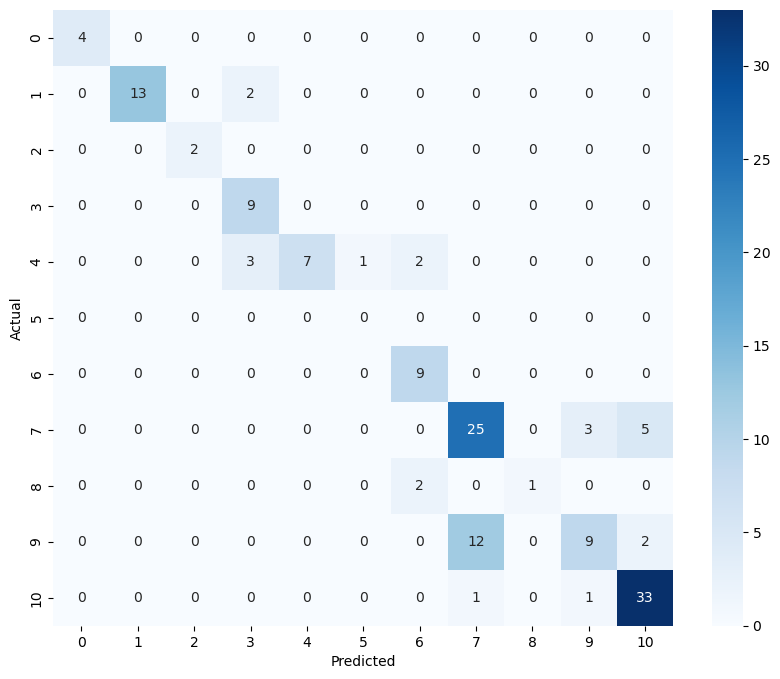

In [ ]:
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
import lightgbm as lgb

best_clf = lgb.LGBMClassifier(
        **study.best_params
)
best_clf.fit(X_train_r, y_train_r)
pred_r = best_clf.predict(X_test_r).ravel()

print("=== Baseline Classification on Random Split ===")
eval_classification(y_test_r, pred_r, name="RandomSplit")

print("\nClassification report (RandomSplit):")
print(classification_report(y_test_r, pred_r, digits=4))

cm_r = confusion_matrix(y_test_r, pred_r, labels=sorted(y_train_r.unique()))
cm_r_df = pd.DataFrame(cm_r, index=sorted(y_train_r.unique()), columns=sorted(y_train_r.unique()))
cm_r_df.to_csv("optuna_baseline_cm_random_wgangp.csv", encoding="utf-8-sig")
print("Saved: optuna_baseline_cm_random_wgangp.csv")

save_preds_csv(X_test_r, y_test_r.values, pred_r, "optuna_baseline_preds_random_cls_wgangp.csv")

# Vẽ Confusion Matrix
plt.figure(figsize=(10,8))
sns.heatmap(confusion_matrix(y_test_r, pred_r), annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()